# Installation

In [70]:
!pip install -r requirements.txt

In [71]:
# Modules
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

# Fonctions
from download_data import download_all
from data_vis import( 
    plot_returns_separately, 
    plot_gold_price_actual_vs_predicted_test, 
    plot_gold_var_residuals,
    plot_gold_var_squared_residuals,
    plot_gold_var_squared_residuals_acf,
    load_and_merge_data,  
    plot_timeseries_multi,
    plot_correlation_heatmap,
    plot_geopolitical_timeline,
    plot_normalized_evolution,
    plot_scatter_matrix,
    plot_return_distributions
)
from time_series_tests import adf_test_all_var_series, print_var_stability_conclusion, print_residual_serial_correlation_conclusion, get_granger_test_summary, granger_tests_for_gold, print_arch_lm_conclusion
from modele import (
    get_var_model_info,
    get_var_summary,
    run_full_var_train_test_pipeline,
    run_reduced_var_train_test_pipeline,
    print_final_lag_selection,
    extract_gold_var_residuals,
    build_garchx_train_dataset,
    fit_garch11_student,
    fit_garch11x_student,
    get_garch_model_info
   
)
from preprocessing import prepare_var_dataset, load_market_data, clean_all_market_data, prepare_daily_macro_exog, split_macro_exog_train_test_by_date

# Import des données

In [72]:
download_all()

  Téléchargement des données
  Période : 2005-01-01 → 2026-04-20

── 1/3  Yahoo Finance ──────────────────────────────
  [gold] Téléchargement Yahoo Finance (GC=F)...
  [gold] ✓ 5351 observations → data\gold.csv
  [dxy] Téléchargement Yahoo Finance (DX-Y.NYB)...
  [dxy] ✓ 5362 observations → data\dxy.csv
  [sp500] Téléchargement Yahoo Finance (^GSPC)...
  [sp500] ✓ 5356 observations → data\sp500.csv
  [vix] Téléchargement Yahoo Finance (^VIX)...
  [vix] ✓ 5356 observations → data\vix.csv

── 2/3  FRED — CPI ─────────────────────────────────
  [cpi] Téléchargement FRED (série CPIAUCSL)...
  [cpi] ✓ 254 observations → data\cpi.csv

── 3/3  GPR — Iacoviello ───────────────────────────
  [gpr] Scraping de la page Iacoviello...
  [gpr] Fichier détecté : https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls
  [gpr] ✓ Fichier brut sauvegardé → data\gpr_raw.xls

  ✓ Tous les fichiers sont dans le dossier data/


### Chargement des données brutes

Dans cette étape, nous chargeons les séries financières qui seront utilisées pour la modélisation et la prédiction du prix de l’or.
Les fichiers ont été préalablement téléchargés depuis Yahoo Finance et sont importés sous forme brute afin d’être nettoyés par la suite.

Les séries utilisées sont les suivantes :

**gold : prix de l’or**
- Il s’agit de la variable cible du projet, que l’on cherche à modéliser et à prédire.

**dxy : US Dollar Index**
- Mesure la valeur du dollar américain et il est généralement inversement corrélé au prix de l’or.

**sp500 : indice S&P 500 index**
- Représente la performance du marché actions américain.

**vix : indice CBOE Volatility Index (VIX)**
- Mesure la volatilité attendue des marchés financiers.
- Une hausse du VIX est souvent associée à une augmentation de la demande d’or

**cpi : inflation**
- Indicateur macroéconomique influençant les politiques monétaires.

**gpr : indice de risque géopolitique**
- Capture les tensions géopolitiques globales.

In [73]:
raw_data = load_market_data(data_dir="data")
raw_data['gold']

,0,1,2,3,4,5,6
0,Price,Adj Close,Close,High,Low,Open,Volume
1,Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
2,Date,NaN,NaN,NaN,NaN,NaN,NaN
3,2005-01-03,428.70001220703125,428.70001220703125,431.0,431.0,431.0,4
4,2005-01-04,428.5,428.5,428.5,428.5,428.5,108
...,...,...,...,...,...,...,...
5349,2026-04-13,4742.39990234375,4742.39990234375,4742.39990234375,4704.0,4704.0,32
5350,2026-04-14,4825.0,4825.0,4841.60009765625,4770.10009765625,4770.10009765625,288
5351,2026-04-15,4800.0,4800.0,4843.60009765625,4798.0,4843.60009765625,182
5352,2026-04-16,4785.39990234375,4785.39990234375,4810.89990234375,4785.39990234375,4810.89990234375,805


Les autres variables présentent la même structure.  
Il est donc nécessaire de restructurer les en-têtes afin de ne conserver que les colonnes pertinentes et d’obtenir un format de données exploitable.

- **Close (prix de clôture) :** dernier prix auquel l’or a été échangé à la fin de la journée.
- **Adj Close (Adjusted Close) :** prix de clôture ajusté pour tenir compte d’événements financiers (dividendes, splits).
- **Open (prix d’ouverture) :** prix du premier échange au début de la journée.
- **High (prix maximum) :** prix le plus élevé atteint durant la journée.
- **Low (prix minimum) :** prix le plus bas atteint durant la journée.
- **Volume :** nombre de contrats échangés au cours de la journée. Il reflète le niveau d’activité du marché.

In [74]:
# Chargement & fusion
df = load_and_merge_data()
df.tail(3)

Chargement des données...
GPR chargé depuis l'onglet 'Sheet1' (495 obs)
DataFrame fusionné : 254 observations, 6 variables
Période : 2005-01-31 → 2026-03-31


,gold,dxy,sp500,vix,cpi,gpr
date,,,,,,
2026-01-31,4713.899902,96.989998,6939.029785,17.440001,326.588,167.800201
2026-02-28,5230.500000,97.610001,6878.879883,19.860001,327.460,121.616882
2026-03-31,4647.600098,99.959999,6528.520020,25.250000,330.293,297.269806


# Préprocessing 

Afin de préparer les données pour la modélisation, un pipeline complet de prétraitement a été implémenté. Celui-ci est encapsulé dans la fonction `prepare_var_dataset`.

Ce pipeline suit les étapes suivantes :

1. **Chargement des données**  
   Les séries financières (or, dollar, S&P500, VIX) sont importées depuis des fichiers CSV.

2. **Nettoyage des données**  
   Les fichiers issus de Yahoo Finance contiennent des lignes d’en-tête parasites.  
   Ces lignes sont supprimées et les colonnes sont restructurées afin d’obtenir un format standard avec :
   - une colonne de date
   - une colonne de prix

3. **Transformation en rendements**  
   Les prix sont transformés en rendements logarithmiques afin d’obtenir des séries stationnaires, adaptées à la modélisation.

4. **Fusion des séries**  
   Les différentes séries sont fusionnées sur la variable temporelle (date) afin d’obtenir un jeu de données cohérent.

5. **Suppression des valeurs manquantes**  
   Les observations incomplètes, notamment dues au calcul des rendements, sont supprimées.

Le résultat est un dataset final contenant les rendements des différentes variables, prêt à être utilisé dans un modèle VAR.

In [75]:
var_df = prepare_var_dataset(data_dir="data")
var_df

,date,gold_ret,dxy_ret,sp500_ret,vix_ret
0,2005-01-04,-0.000467,0.015500,-0.011740,-0.007128
1,2005-01-05,-0.004444,-0.000363,-0.003634,0.007838
2,2005-01-06,-0.013214,0.007363,0.003500,-0.036867
3,2005-01-07,-0.005001,0.005517,-0.001432,-0.006649
4,2005-01-10,0.000477,-0.003835,0.003417,-0.019462
...,...,...,...,...,...
5341,2026-04-13,-0.004103,-0.002842,0.010122,-0.005737
5342,2026-04-14,0.017267,-0.002545,0.011714,-0.040561
5343,2026-04-15,-0.005195,-0.000612,0.007944,-0.010403
5344,2026-04-16,-0.003046,0.001630,0.002607,-0.012739


# Visualisation

In [76]:
# 3.1 — Séries temporelles (6 panneaux, base 100)
plot_timeseries_multi(df)

[Plotly] Séries temporelles → figures\timeseries_multi.html


In [77]:
# 3.2 — Heatmap des corrélations (niveaux + différences premières)
plot_correlation_heatmap(df)

[Plotly] Heatmap corrélations → figures\correlation_heatmap.html


In [78]:
# 3.3 — Timeline géopolitique (or + GPR + événements annotés)
plot_geopolitical_timeline(df)

[Plotly] Timeline géopolitique → figures\geopolitical_timeline.html


In [79]:
# 3.4 — Évolution normalisée sur un seul graphique (style cluster lines)
plot_normalized_evolution(df)

[Plotly] Évolution normalisée → figures\normalized_evolution.html


In [80]:
# 3.5 — Scatter matrix complète (pairplot coloré par niveau de l'or)
plot_scatter_matrix(df)

[Plotly] Scatter matrix → figures\scatter_matrix.html


In [81]:
raw_data = load_market_data()
cleaned_data = clean_all_market_data(raw_data)
cleaned_data.keys()
gold = cleaned_data["gold"]
dxy = cleaned_data["dxy"]
sp500 = cleaned_data["sp500"]
vix = cleaned_data["vix"]
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
df = gold.merge(dxy, on="date", how="inner") \
         .merge(sp500, on="date", how="inner") \
         .merge(vix, on="date", how="inner")

df = df.sort_values("date")

In [82]:
'''for col in ["gold_price", "sp500_price", "dxy_price", "vix_price"]:
    df_norm[col] = df_norm[col] / df_norm[col].iloc[0] * 100

plt.figure()
sns.lineplot(data=df_norm, x="date", y="gold_price", label="Gold")
sns.lineplot(data=df_norm, x="date", y="sp500_price", label="SP500")
sns.lineplot(data=df_norm, x="date", y="dxy_price", label="DXY")
sns.lineplot(data=df_norm, x="date", y="vix_price", label="VIX")
plt.title("Comparaison des actifs (base 100)")
plt.ylabel("Base 100")
plt.show()
# J'ai fais une fonctions qui fais ça : plot_all_prices()'''


'for col in ["gold_price", "sp500_price", "dxy_price", "vix_price"]:\n    df_norm[col] = df_norm[col] / df_norm[col].iloc[0] * 100\n\nplt.figure()\nsns.lineplot(data=df_norm, x="date", y="gold_price", label="Gold")\nsns.lineplot(data=df_norm, x="date", y="sp500_price", label="SP500")\nsns.lineplot(data=df_norm, x="date", y="dxy_price", label="DXY")\nsns.lineplot(data=df_norm, x="date", y="vix_price", label="VIX")\nplt.title("Comparaison des actifs (base 100)")\nplt.ylabel("Base 100")\nplt.show()\n# J\'ai fais une fonctions qui fais ça : plot_all_prices()'

In [83]:
'''plt.figure()
sns.lineplot(data=df_norm, x="date", y="gold_price", label="Gold")
sns.lineplot(data=df_norm, x="date", y="vix_price", label="VIX")
plt.title("Or vs VIX (actif refuge ?)")
plt.show()'''


'plt.figure()\nsns.lineplot(data=df_norm, x="date", y="gold_price", label="Gold")\nsns.lineplot(data=df_norm, x="date", y="vix_price", label="VIX")\nplt.title("Or vs VIX (actif refuge ?)")\nplt.show()'

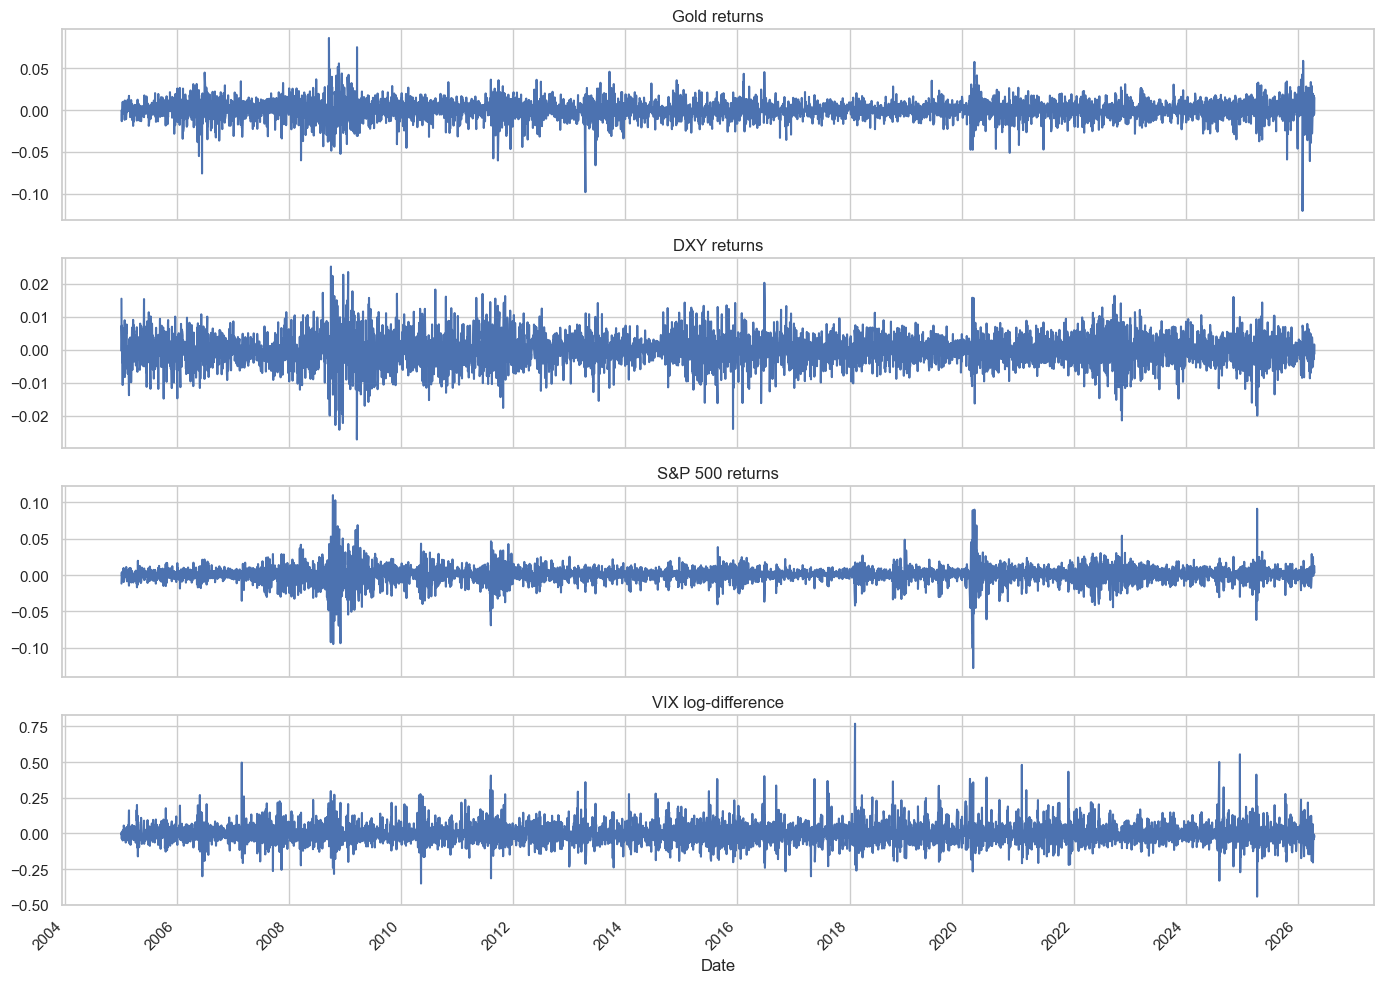

In [84]:
plot_returns_separately(var_df)

# Distribution des rendements - Tests de normalité 

Nous analysons la distribution des rendements logarithmiques des différentes séries financières afin de vérifier certaines hypothèses statistiques clés avant la modélisation. 
L’objectif est de comparer la distribution empirique des rendements à une distribution normale, à l’aide :
- d’un histogramme
- d’une densité empirique (KDE)
- d’une loi normale théorique
 des moments statistiques (skewness, kurtosis)
- du test de normalité de Jarque-Bera


### Skewness (asymétrie)

La skewness mesure le degré d’asymétrie d’une distribution autour de sa moyenne. 

Elle permet d’identifier si les valeurs extrêmes se situent davantage à gauche ou à droite de la distribution.

### Définition formelle

Pour une variable aléatoire X, la skewness est définie par :
$
\text{Skewness}(X) = \frac{\mathbb{E}[(X - \mu)^3]}{\sigma^3}
$

Dans le cas d’un échantillon de taille n:
$
\widehat{\text{Skewness}} = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^3
$


### Interprétation

- Skewness = 0 : distribution symétrique (proche d’une loi normale)
- Skewness < 0 : asymétrie à gauche, indiquant des valeurs extrêmes négatives plus fréquentes
- Skewness > 0 : asymétrie à droite, indiquant des valeurs extrêmes positives plus fréquentes

---

### Kurtosis (aplatissement / queues de distribution)

La kurtosis mesure l’épaisseur des queues d’une distribution, c’est-à-dire la fréquence des événements extrêmes par rapport à une distribution normale.

### Définition formelle

Pour une variable aléatoire :
$
\text{Kurtosis}(X) = \frac{\mathbb{E}[(X - \mu)^4]}{\sigma^4}
$

Pour un échantillon :
$
\widehat{\text{Kurtosis}} = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^4
$

### Interprétation

- Kurtosis ≈ 0 (excès) : distribution proche de la normale
- Kurtosis > 0 : queues épaisses (fat tails), présence fréquente d’événements extrêmes
- Kurtosis < 0 : queues fines, distribution plus plate et moins d’extrêmes

---

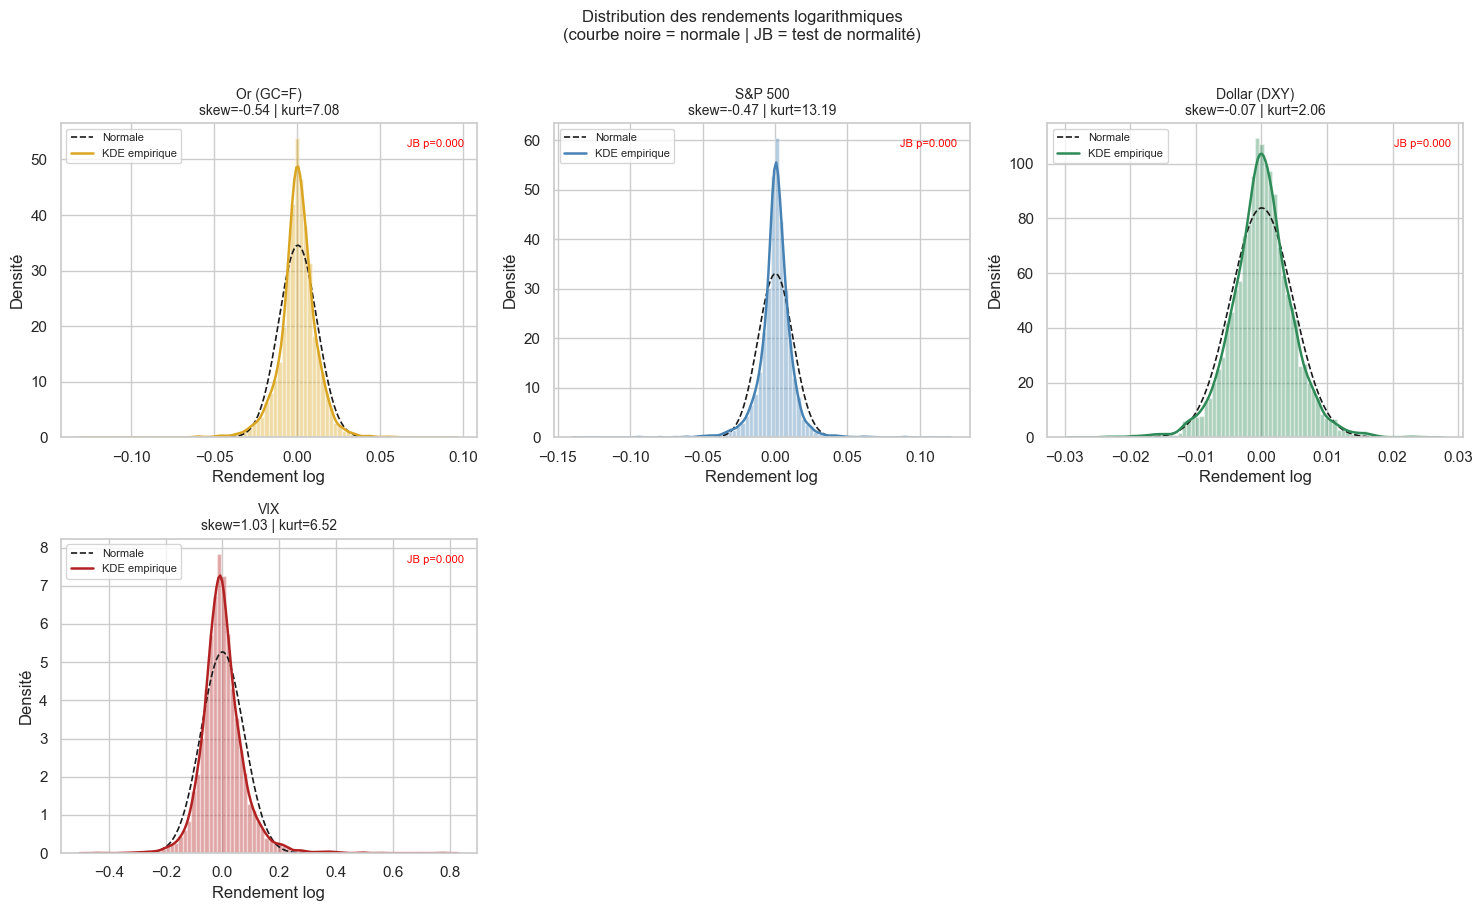

In [85]:
plot_return_distributions(var_df)

### Interprétation 
Pour toutes les séries, la p-value du test JB est 0.000. Donc, on rejette la normalité

Conclusion: les rendements financiers ne suivent pas une loi normale.

**kurtosis**
- Gold :  = 7.08
- S&P 500 : 13.19 
- VIX : 6.52
- DXY : 2.06 (moins extrême)

Toutes les séries ont des valeurs > 0, ce qui implique la présence de queues épaisses.

**Skewness**
- Gold : légèrement négative
- S&P 500 < 0 : asymétrie négative
- VIX > 0 : asymétrie positive
- DXY proche de 0 : distribution relativement symétrique


Les modèles de type Vector Autoregression (VAR) reposent généralement sur des hypothèses implicites de normalité des résidus. Or, la présence de skewness non nulle et de kurtosis élevée dans les données financières indiquent la présence de chocs importants et une déviation significative par rapport à la normalité impliquant une sous-estimation des événements extrêmes et une limitation dans la modélisation des chocs de marché.

# TEST sur les séries

Test ADF qui vérifie la stationarité des séries (returns)

In [87]:
adf_results = adf_test_all_var_series(var_df)
adf_results 

,series,adf_statistic,p_value,used_lags,n_obs,critical_value_1pct,critical_value_5pct,critical_value_10pct,stationary_5pct
0,gold_ret,-29.192763,0.000000e+00,6,5339,-3.431575,-2.862082,-2.567058,True
1,dxy_ret,-22.026304,0.000000e+00,10,5335,-3.431576,-2.862082,-2.567058,True
2,sp500_ret,-16.349991,2.938877e-29,19,5326,-3.431578,-2.862083,-2.567059,True
3,vix_ret,-29.409758,0.000000e+00,8,5337,-3.431576,-2.862082,-2.567058,True


On a donc des p-value > 0.05 donc l'ensemble des séries sont stationaires 

# VAR

## Modélisation 

In [88]:
full_var_results = run_full_var_train_test_pipeline(
    var_df=var_df,
    price_df=price_df,
    train_start="2005-01-01",
    train_end="2020-12-31",
    test_start="2021-01-01",
    test_end="2025-12-31",
    window_years=7,
    step_years=2,
    max_lag=10,
    price_reconstruction_mode="dynamic"
)
plot_gold_price_actual_vs_predicted_test(full_var_results["gold_price_forecast_df"])

NameError: name 'price_df' is not defined

In [ ]:
reduced_var_results = run_reduced_var_train_test_pipeline(
    var_df=var_df,
    price_df=price_df,
    train_start="2005-01-01",
    train_end="2020-12-31",
    test_start="2021-01-01",
    test_end="2025-12-31",
    window_years=7,
    step_years=2,
    max_lag=10
)
print_final_lag_selection(reduced_var_results["final_lag_dict"])
reduced_var_results["lag_summary_df"]
reduced_var_results["final_lag"]
print(get_var_summary(reduced_var_results["fitted_model"]))
get_var_model_info(reduced_var_results["fitted_model"])
reduced_var_results["gold_price_forecast_df"].head()
plot_gold_price_actual_vs_predicted_test(reduced_var_results["gold_price_forecast_df"])

In [ ]:
full_var_results["gold_price_forecast_df"].head(20)

## Test sur le VAR

TEST de la stabilité du VAR 

In [ ]:
fitted_model = full_var_results["fitted_model"]
print_var_stability_conclusion(fitted_model)

Le VAR est donc stable 

TEST d'autocorrélation des résidus 

In [ ]:
print_residual_serial_correlation_conclusion(fitted_model, nlags=12)

Bien que le VAR(3) soit stable, le test de Portmanteau rejette nettement l’hypothèse d’absence d’autocorrélation résiduelle. Cela suggère que la structure dynamique du système n’est pas entièrement capturée par trois retards

TEST de causalité de granger 

In [ ]:
granger_results = granger_tests_for_gold(fitted_model)
granger_results

Ainsi, à fréquence journalière, les variations du dollar et du stress de marché contiennent de l’information utile pour prévoir l’or, davantage que les rendements actions eux-mêmes.

Retrait du Sp500

In [ ]:
fitted_model = reduced_var_results["fitted_model"]
print_var_stability_conclusion(fitted_model)

In [ ]:
print_residual_serial_correlation_conclusion(fitted_model, nlags=12)

In [ ]:
granger_results_reduced = pd.DataFrame([
    get_granger_test_summary(fitted_model, caused="gold_ret", causing="dxy_ret"),
    get_granger_test_summary(fitted_model, caused="gold_ret", causing="vix_ret"),
])

granger_results_reduced

Le retrait du S&P 500 améliore la qualité du VAR et confirme que les déterminants les plus utiles pour l’or sont le dollar et le VIX. En revanche, le test de whiteness restant rejeté, le modèle à 3 variables ne constitue pas encore une spécification pleinement satisfaisante du point de vue dynamique.


# VAR-GARCH-X 

Au vu de nos résultats, un VAR-GARCH-X se justifie car le DXY et le VIX ont un pouvoir prédictif sur les rendements de l’or, tandis que la dynamique résiduelle restante suggère qu’il faut modéliser non seulement la moyenne conditionnelle, mais aussi la volatilité conditionnelle.

## Préprocessing

In [ ]:
gold_resid_train_df = extract_gold_var_residuals(reduced_var_results["fitted_model"])
plot_gold_var_residuals(gold_resid_train_df)
plot_gold_var_squared_residuals(gold_resid_train_df)
plot_gold_var_squared_residuals_acf(gold_resid_train_df, lags=30)

In [ ]:
print_arch_lm_conclusion(gold_resid_train_df, nlags=12)

Les résidus de l’équation de l’or issus du VAR présentent un effet ARCH significatif. Le VAR ne suffit donc pas à décrire entièrement la dynamique de la série. Il est pertinent de compléter la modélisation de la moyenne par un modèle GARCH-X afin de capturer la variance conditionnelle résiduelle.

## Modéliastion du VAR-GARCH-X

In [ ]:
macro_exog_df = prepare_daily_macro_exog(
    data_dir="data",
    daily_calendar_df=var_df[["date"]]
)

macro_train_df, macro_test_df = split_macro_exog_train_test_by_date(
    macro_exog_df=macro_exog_df,
    train_start="2005-01-01",
    train_end="2020-12-31",
    test_start="2021-01-01",
    test_end="2025-12-31"
)

garchx_train_df = build_garchx_train_dataset(
    gold_resid_train_df=gold_resid_train_df,
    macro_train_df=macro_train_df
)

VAR-GARCH(1,1)

In [ ]:
garch11_student_res = fit_garch11_student(
    gold_resid_train_df=gold_resid_train_df
)

get_garch_model_info(garch11_student_res)

VAR-GARCH-X

In [ ]:
garch11x_student_res = fit_garch11x_student(
    garchx_train_df=garchx_train_df
)

get_garch_model_info(garch11x_student_res)

Comparaison des deux modèles

In [ ]:
comparison_df = pd.DataFrame([
    get_garch_model_info(garch11_student_res),
    get_garch_model_info(garch11x_student_res)
])

comparison_df

## Prédiction 

## Test sur le VAR-GARCH-X